Using device: cpu
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth


100%|███████████████████████████████████████████████████████████████████████████████| 548M/548M [02:46<00:00, 3.45MB/s]



Starting Neural Style Transfer...
  Step  50/300 | Content Loss: nan | Style Loss: nan
  Step 100/300 | Content Loss: nan | Style Loss: nan
  Step 150/300 | Content Loss: nan | Style Loss: nan
  Step 200/300 | Content Loss: nan | Style Loss: nan
  Step 250/300 | Content Loss: nan | Style Loss: nan
  Step 300/300 | Content Loss: nan | Style Loss: nan


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\transforms\functional.py:282: RuntimeWarning: invalid value encountered in cast
  npimg = (npimg * 255).astype(np.uint8)



Output saved to: nst_output.jpg


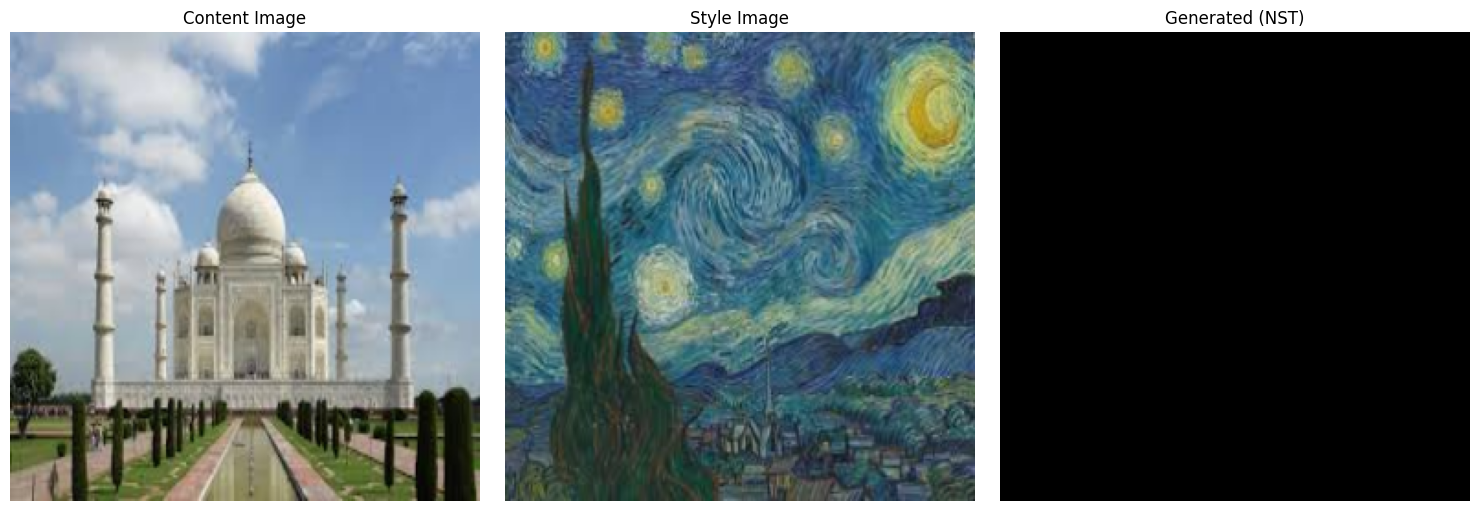

Comparison saved to: nst_comparison.jpg


In [2]:
# Saee Surve
# Experiment: Neural Style Transfer using Deep Learning (VGG19)

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import copy

# ─── Config ──────────────────────────────────────────────────────────────────
CONTENT_PATH  = "content.jpg"       # ← change to your content image path
STYLE_PATH    = "style.jpg"         # ← change to your style image path
OUTPUT_PATH   = "nst_output.jpg"
IMG_SIZE      = 256                 # reduce to 128 if CPU is slow
NUM_STEPS     = 300
CONTENT_WEIGHT = 1e4
STYLE_WEIGHT   = 1e6
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ─── Image Utilities ──────────────────────────────────────────────────────────
def load_image(path, size=IMG_SIZE):
    img = Image.open(path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    return transform(img).unsqueeze(0).to(DEVICE)

def tensor_to_image(tensor):
    img = tensor.clone().squeeze(0)
    # reverse normalization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img  = img.cpu() * std + mean
    img  = img.clamp(0, 1)
    return transforms.ToPILImage()(img)

# ─── Loss Functions ───────────────────────────────────────────────────────────
class ContentLoss(nn.Module):
    def __init__(self, target):
        super().__init__()
        self.target = target.detach()

    def forward(self, x):
        self.loss = nn.functional.mse_loss(x, self.target)
        return x

def gram_matrix(tensor):
    b, c, h, w = tensor.size()
    features   = tensor.view(c, h * w)
    return torch.mm(features, features.t()) / (c * h * w)

class StyleLoss(nn.Module):
    def __init__(self, target):
        super().__init__()
        self.target = gram_matrix(target).detach()

    def forward(self, x):
        self.loss = nn.functional.mse_loss(gram_matrix(x), self.target)
        return x

# ─── Build Model with Loss Layers ─────────────────────────────────────────────
CONTENT_LAYERS = ['conv_4']
STYLE_LAYERS   = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

def build_model(content_img, style_img):
    vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(DEVICE).eval()

    content_losses, style_losses = [], []
    model = nn.Sequential()
    conv_count = 0

    for layer in vgg.children():
        if isinstance(layer, nn.Conv2d):
            conv_count += 1
            name = f"conv_{conv_count}"
        elif isinstance(layer, nn.ReLU):
            name  = f"relu_{conv_count}"
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f"pool_{conv_count}"
        elif isinstance(layer, nn.BatchNorm2d):
            name = f"bn_{conv_count}"
        else:
            continue

        model.add_module(name, layer)

        if name in CONTENT_LAYERS:
            cl = ContentLoss(model(content_img))
            model.add_module(f"content_loss_{conv_count}", cl)
            content_losses.append(cl)

        if name in STYLE_LAYERS:
            sl = StyleLoss(model(style_img))
            model.add_module(f"style_loss_{conv_count}", sl)
            style_losses.append(sl)

        # stop after last needed layer
        if conv_count >= 5:
            break

    return model, content_losses, style_losses

# ─── NST Optimization ─────────────────────────────────────────────────────────
def run_nst(content_img, style_img):
    # start from content image
    generated = content_img.clone().requires_grad_(True)
    model, content_losses, style_losses = build_model(content_img, style_img)

    optimizer = optim.LBFGS([generated])
    step = [0]

    print("\nStarting Neural Style Transfer...")
    while step[0] < NUM_STEPS:
        def closure():
            with torch.no_grad():
                generated.clamp_(0, 1)

            optimizer.zero_grad()
            model(generated)

            c_loss = sum(cl.loss for cl in content_losses) * CONTENT_WEIGHT
            s_loss = sum(sl.loss for sl in style_losses)   * STYLE_WEIGHT
            total  = c_loss + s_loss
            total.backward()

            step[0] += 1
            if step[0] % 50 == 0:
                print(f"  Step {step[0]:>3}/{NUM_STEPS} | "
                      f"Content Loss: {c_loss.item():.2f} | "
                      f"Style Loss: {s_loss.item():.2f}")
            return total

        optimizer.step(closure)

    with torch.no_grad():
        generated.clamp_(0, 1)

    return generated

# ─── Main ─────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    content_img = load_image(CONTENT_PATH)
    style_img   = load_image(STYLE_PATH)

    output_tensor = run_nst(content_img, style_img)
    output_image  = tensor_to_image(output_tensor)
    output_image.save(OUTPUT_PATH)
    print(f"\nOutput saved to: {OUTPUT_PATH}")

    # ─── Display ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    titles = ["Content Image", "Style Image", "Generated (NST)"]
    images = [
        tensor_to_image(content_img),
        tensor_to_image(style_img),
        output_image
    ]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("nst_comparison.jpg")
    plt.show()
    print("Comparison saved to: nst_comparison.jpg")